# K-Nearest Neighbours (KNN) <a id="k-nearest-neighbours"></a>

## Table of Contents
* [K-Nearest Neighbouts (KNN)](#k-nearest-neighbours)
    * [KNN Algorithms](#knn-algorithms)
        * [Ball Tree](#ball-tree)
        * [KD Tree](#kd-tree)

K-Nearest Neighbours (KNN), similarly to Decision Trees and Random Forests, is one of the algorithms that is remarkable for its simplicity, but becomes increasingly more complicated as we dive deeper into it. However, we shall start slow and leave the more complex matters for later.

Consider a given point, with two features $(x_{1}, x_{2})$, that you want to classify. In KNN, we check the class of the K nearest points and use them as votes for the point we want to classify. The class that is the most voted across the K selected neighbours, is the class attributed to the given point. This is the basic idea of a KNN Classifier, from which you may raise many questions that hopefully will be answered below.

The first question we can raise is: how do we calculate the distance between our given point and any other point from which we know the class? By default, the distance metric considered is the Euclidean Distance, but other plausible contestants are considered. In [distances.ipynb](./metrics/distances.ipynb) you can find more information on the most common distances used. The scikit-learn library defaults to the Minkowski distance (with $p = 2$, which means it is, effectively, the Euclidean distance), but any other distance described in the mentioned notebook can be used, including the arguments mentioned.

If you wonder about the fairness of using the votes of the K-Nearest Neighbours to decide the a determined points class, no matter how far these points are, it is often to introduce a weighting algorithm. By default, each neighbours class weights the same, but in scenarios where the data is very sparse it is adequate to attribute a vote importance (weight) based on the distance the neighbouring points are from the one we desire to classify. scikit-learn allows you to use the distance as the weight of a neighbour vote, but that might be insufficient for your use case. For example, to compensate for the low number of samples of a certain class, you may attribute a larger weight to the neighbors belonging to it. You are free to integrate any weight metric that may suit your problem.

Because this algorithm is a lazy learner Machine Learning algorithm (it only learns from the training set in inference, when you are given the data point), calculating which are the K-nearest neighbours becomes an engineering problem as your dataset grows bigger. For small datasets, you can just compute the distances to all points (brute-force search) and it is the most intuitive way of thinking about KNN for the first time. However, imagine you have to find the K-nearest neighbours in a dataset with millions of points. For each point you want to classify, you will spend significant amounts of time to provide an expected label, and as you can see, a trivial approach soon becomes hard to compute. Without you having to think about it, scikit-learn selects between brute-forcing the search or using one of two other algorithms: Ball Tree or K-Dimensional Tree (or just KD Tree).

Let's start with the simpler and easier to understand approach: brute-force.

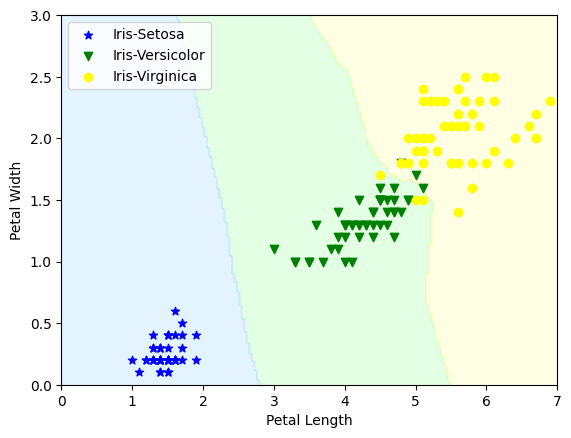

In [14]:
"""Beginning of KNN code examples."""
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
k = 5
X = iris["data"][:, 2:]
y = iris["target"]

# Euclidean distance
def calc_dist_euclidean(point1, point2):
    """Calculates the Euclidean distance between two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    # Get the distance of the point to every other
    # point in the training set (we considered the
    # whole dataset for demonstration purposes)
    for idx, train_point in enumerate(x_train):
        euclidean_distance = calc_dist_euclidean(point, train_point)
        dists.append((euclidean_distance, y_train[idx]))

    # Sort ascending
    dists.sort(key=lambda tup: tup[0])
    # Get the K closest points
    votes = dists[:k_neigh]
    # Count the total number of votes per class in
    # these K points
    total_votes = np.zeros(len(np.unique(y_train)))
    for vote in votes:
        total_votes[vote[1]] += 1
    # Prediction is the class with the largest amount
    # of votes (in a tie scenario, picks the one with
    # lowest index)
    return int(np.argmax(total_votes))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = predict_knn(x_train=X,
                                      y_train=y,
                                      point=data_points[sample, :],
                                      k_neigh=k)

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


The same code implemented using `scikit-learn` becomes much less verbose, while getting the same results, as seen below:

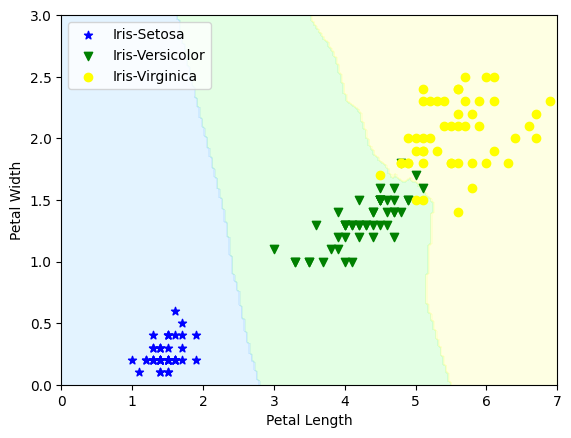

In [15]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.neighbors import KNeighborsClassifier
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

iris = cast(Dict, datasets.load_iris())
k = 5
X = iris["data"][:, 2:]
y = iris["target"]
knn_model = KNeighborsClassifier(n_neighbors=k).fit(np.array(X), np.array(y))

x_min, x_max = 0, 7
y_min, y_max = 0, 3

# Creates a dataset with every point in the plot, to
# show the predicted class in each set of coordinates
# and plots it
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample] = knn_model.predict(np.array([data_points[sample, :]]))[0]

predictions = predictions.reshape(xx.shape)

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.legend(loc=2)
plt.show()


In the interactive code below, you can choose a set of coordinates (which will appear in the color pink and with the marker of the predicted class) and its corresponding K closest points will appear as red!

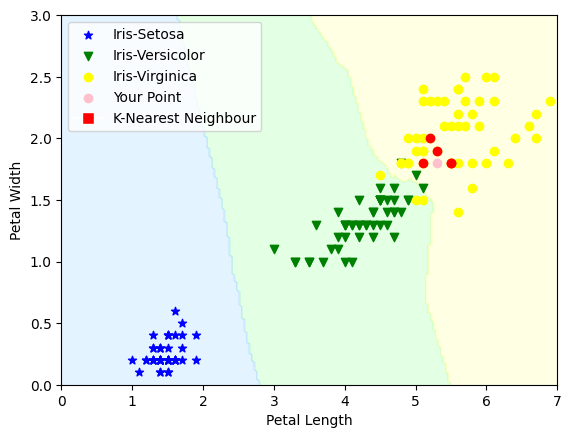

In [16]:
from typing import cast, Dict
from sklearn import datasets
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

def calc_dist_euclid_2(point1, point2):
    """Calculates the Euclidean distance between
    two given points."""
    current_sum = 0
    for coord in range(X.shape[1]):
        current_sum += (point1[coord] - point2[coord]) ** 2
    return current_sum ** ( 1 / 2 )

def predict_knn_2(x_train, y_train, point, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist_euclid_2(point, train_point)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_list = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_list.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_list

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

predictions = np.zeros(data_points.shape[0])
for sample in range(data_points.shape[0]):
    predictions[sample], _ = predict_knn_2(x_train=X,
                                           y_train=y,
                                           point=data_points[sample, :],
                                           k_neigh=k)

predictions = predictions.reshape(xx.shape)

your_point_class = int(predict_knn_2(X, y, point=your_point, k_neigh=k)[0])
k_neighbours = predict_knn_2(X, y, point=your_point, k_neigh=k)[1]

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

plt.scatter(your_point[0],
            your_point[1],
            marker=label_to_marker[your_point_class],
            c="pink",
            label="Your Point")

for neighbour_idx in range(k):
    marker = label_to_marker[k_neighbours[neighbour_idx][1]]
    plt.scatter(
        k_neighbours[neighbour_idx][0][0],
        k_neighbours[neighbour_idx][0][1],
        marker=marker,
        c="red"
    )

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='K-Nearest Neighbour'
)
handles, labels = plt.gca().get_legend_handles_labels()

handles.append(knn_legend)
labels.append("K-Nearest Neighbour")

plt.legend(handles, labels, loc=2)

plt.xlabel("Petal Length")
plt.ylabel("Petal Width")
plt.show()


In this example, we hand-coded most commonly used distance to show you a quick draft on the decision boundaries imposed by this algorithm on our given dataset. But, as you could have noticed by exploring the [distances notebook](./metrics/distances.ipynb), there are multiple distance metrics that can be used in the KNN algorithm and each of these provides different classification boundaries. Below, some distance metrics were selected and plotted to show you the impact that the metric selection has.

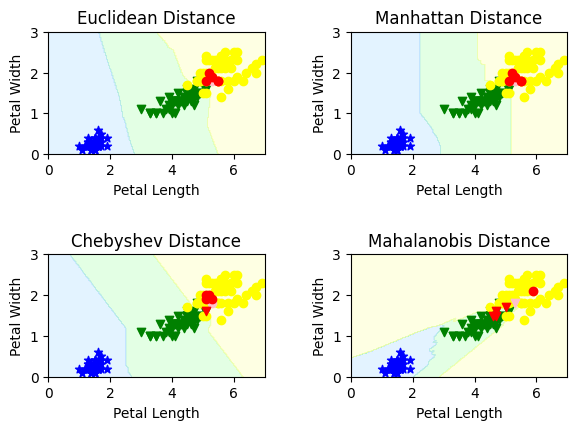

In [17]:
from typing import cast, Dict
from sklearn import datasets
from sklearn.metrics import DistanceMetric
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from math import ceil

your_point = [5.3, 1.8] # your point with coordinates [x,y]

iris = cast(Dict, datasets.load_iris())
X = iris["data"][:, 2:]
y = iris["target"]

k = 5

distances = {
    "euclidean": DistanceMetric.get_metric('euclidean'),
    "manhattan": DistanceMetric.get_metric('manhattan'),
    "chebyshev": DistanceMetric.get_metric('chebyshev'),
    "mahalanobis": DistanceMetric
}

def get_dist(dist_name, x: np.ndarray | None) -> DistanceMetric:
    """Gets the corresponding DistanceMetric object for a given
    distance name."""
    if dist_name == 'mahalanobis' and x is not None:
        # rowvar=False indicates that the variables are represented in the
        # columns rather than the rows
        return DistanceMetric.get_metric('mahalanobis', V=np.cov(x, rowvar=False))
    return distances[dist_name]

def calc_dist(dist_name, point1, point2, x: None):
    """Calculates the selected distance between two given points.
    In case the calculated distance is Mahalanobis, requires the
    `x` matrix."""
    dist_fun = get_dist(dist_name, x)
    dist_scalar = dist_fun.pairwise(np.array([point1]),
                                    np.array([point2]))
    return dist_scalar

def predict_knn_3(x_train, y_train, point, dist_name, k_neigh):
    """Predicts a given point class based on the 
    number of votes from the top-k neighbours."""
    dists = []
    for idx, train_point in enumerate(x_train):
        dist = calc_dist(dist_name, point, train_point, x_train)
        dists.append((dist, y_train[idx], train_point))

    dists.sort(key=lambda tup: tup[0])
    votes = dists[:k_neigh]
    total_votes = np.zeros(len(np.unique(y_train)))
    k_neighbours_md = []
    for vote in votes:
        total_votes[vote[1]] += 1
        k_neighbours_md.append((vote[2], vote[1]))
    return np.argmax(total_votes), k_neighbours_md

x_min, x_max = 0, 7
y_min, y_max = 0, 3

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

data_points = np.c_[xx.ravel(), yy.ravel()]

ROWS = 2
cols = ceil(len(distances.keys()) / 2)
fig, axes = plt.subplots(ROWS, cols)
axes = axes.flatten()

for index, distance_name in enumerate(distances):
    predictions = np.zeros(data_points.shape[0])
    for sample in range(data_points.shape[0]):
        predictions[sample], _ = predict_knn_3(x_train=X,
                                               y_train=y,
                                               point=data_points[sample, :],
                                               dist_name=distance_name,
                                               k_neigh=k)

    predictions = predictions.reshape(xx.shape)

    your_point_class = int(predict_knn_3(X,
                                         y,
                                         point=your_point,
                                         dist_name=distance_name,
                                         k_neigh=k)[0])
    k_neighbours = predict_knn_3(X,
                                 y,
                                 point=your_point,
                                 dist_name=distance_name,
                                 k_neigh=k)[1]

    X_setosa = X[y==0]
    X_versicolor = X[y==1]
    X_virginica = X[y==2]

    cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

    axes[index].axis((0.,7., 0.,3.))
    axes[index].contourf(xx, yy, predictions, alpha=0.3, cmap=cmap)
    axes[index].scatter(X_setosa[:,0],
                X_setosa[:,1],
                marker="*",
                c="blue", label="Iris-Setosa")
    axes[index].scatter(X_versicolor[:,0],
                X_versicolor[:,1],
                marker="v",
                c="green",
                label="Iris-Versicolor")
    axes[index].scatter(X_virginica[:,0],
                X_virginica[:,1],
                marker="o",
                c="yellow",
                label="Iris-Virginica")

    label_to_marker = {
        0: "*",
        1: "v",
        2: "o",
    }

    axes[index].scatter(your_point[0],
                your_point[1],
                marker=label_to_marker[your_point_class],
                c="pink",
                label="Your Point")

    for neighbour_idx in range(k):
        marker = label_to_marker[k_neighbours[neighbour_idx][1]]
        axes[index].scatter(
            k_neighbours[neighbour_idx][0][0],
            k_neighbours[neighbour_idx][0][1],
            marker=marker,
            c="red"
        )

    axes[index].set_xlabel("Petal Length")
    axes[index].set_ylabel("Petal Width")

    axes[index].set_title(f"{distance_name.capitalize()} Distance")

plt.tight_layout(pad=2.5)
plt.show()


The multiple graphics generated above are illustrative of the different decision boundaries created when varying the distance metric. The boundaries both in Manhattan and Chebyshev can be described through linear equations, without much of a curvature and rather incremental steps. This trend becomes easier to spot in the points further away from the features data points. It is easy to develop some intuition in these distances, as well as in the Euclidean distance, as the points that appear visually closer tend to be the closest neighbours. However, the Mahalanobis distance shows some stranger decision boundaries that are hard to visualize without plotting it. In this distance, it is possible to see in the graphic that even though the yellow points are the furthest (considering Euclidean distance) from those that have a petal length smaller than 2, these are the ones that are closer in the Mahalanobis distance. This happens because of the larger variance seen in both variables of the yellow data points. To develop some intuition, see this as the probability of a point in the plot belonging to a specific class: if a point appears further away from the data points, then it most likely belongs to the class with highest variance. Therefore, it is also safe to extend our thought to the fact that the closest point from class A to any point P, in the Mahalanobis distance, is always the point closest to the mean point of that class A.

## KNN Algorithms <a id="knn-algorithms"></a>

To make a prediction, we calculated the distance of a point to all other points in the dataset. As mentioned, this becomes a hassle when the number of points in the dataset or the number of predictions to be made increases. To mitigate this issue, two different algorithms are used to avoid computing the distance total points in the dataset: Ball Tree and KD Tree. Each of those algorithms will be explored below, as an exercise to develop intuition regarding their use. However, in practice, the decision of which algorithm is abstracted from the user and handled by the called API (e.g. `scikit-learn`). In both algorithms, we are building a decision tree that will allow the nearest neighbours faster, utilizing binary tree search principles. As the algorithm switches from brute force to a tree-based algorithm, it stops being classified as lazy: it now learns patterns in the training data that later applies to new data. Because of this, the KNN algorithm object implemented in `scikit-learn` has a method called `.fit()`, despite at first glance looking redundant.

### Ball Tree <a id="ball-tree"></a>

A ball tree is a binary tree in which every node defines a D-dimensional ball containing a subset of points to be searched. Each node splits the dataset in two disjoint sets (balls). The balls may still intersect, but one point is always attributed to a single ball in a node. Each node is represented by the smallest ball that contains all data points in its subtree. Below, you will find a demonstration on how the Ball Tree is constructed.

In [19]:
# Loading data
from typing import cast, Dict
from sklearn.datasets import load_iris

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:]
y = iris['target']

random_state = 8


The first step in building a ball tree is randomly selecting a point from the dataset (shown in red in the resulting graphic):

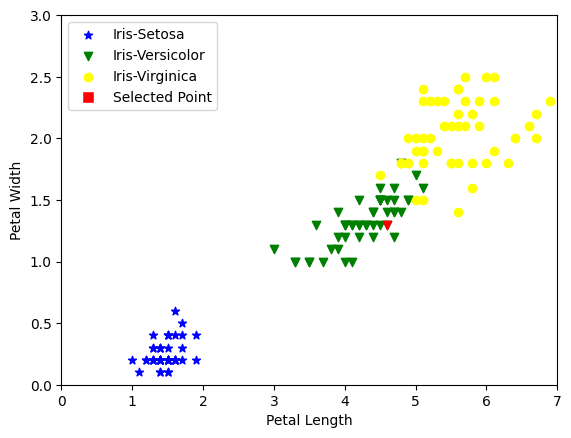

In [20]:
from random import choice, seed
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

seed(random_state)
initial_random_point = choice(X)
initial_random_point_class = choice(y)


x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(initial_random_point[0],
            initial_random_point[1],
            marker=label_to_marker[initial_random_point_class],
            c="red")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

knn_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='Random Point'
)
handles, labels = plt.gca().get_legend_handles_labels()

handles.append(knn_legend)
labels.append("Selected Point")

plt.legend(handles, labels, loc=2)

plt.show()


After selecting a random point, the brute-force algorithm is applied to find the point that stands the furthest away from the random point. Similarly to brute-force, any appropriate distance algorithm may be selected. Here, for simplicity purposes, the Euclidean distance was selected. 

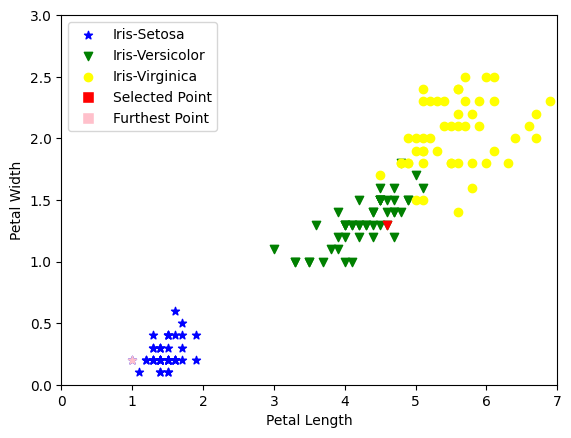

In [21]:
def euclidean_dist(point1, point2):
    """Calculates the Euclidean distance between two points"""
    dist = 0
    for idx, _ in enumerate(point1):
        coord_diff = point1[idx] - point2[idx]
        dist += coord_diff ** 2
    return dist ** (1 / 2)

distances = []
for i, train_p in enumerate(X):
    distance = euclidean_dist(initial_random_point, train_p)
    distances.append((distance, train_p, y[i]))

distances.sort(key=lambda tup: tup[0], reverse=True)
furthest_point = distances[0][1]
furthest_point_class = distances[0][2]

x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(initial_random_point[0],
            initial_random_point[1],
            marker=label_to_marker[initial_random_point_class],
            c="red")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

random_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='red',
    markersize=8,
    label='Random Point'
)

furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(random_point_legend)
handles.append(furthest_point_legend)
labels.append("Selected Point")
labels.append("Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()


Parting from the calculated furthest point (pink in the image above) the furthest point relative to it is found using brute-force again, as follows: 

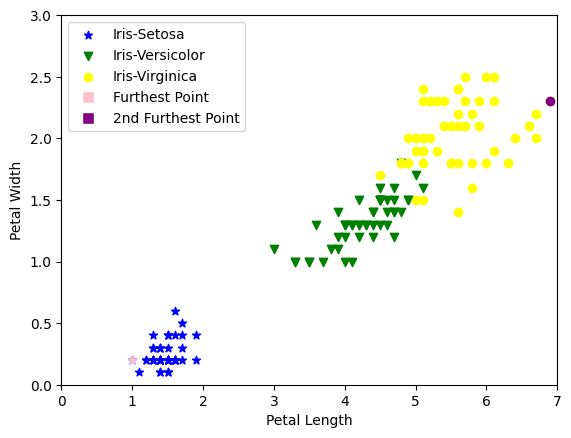

In [22]:
def euclidean_dist_2(point1, point2):
    """Calculates the Euclidean distance between two points"""
    dist = 0
    for idx, _ in enumerate(point1):
        coord_diff = point1[idx] - point2[idx]
        dist += coord_diff ** 2
    return dist ** (1 / 2)


distances = []
for index, t_point in enumerate(X):
    distance = euclidean_dist(furthest_point, t_point)
    distances.append((distance, t_point, y[index]))

distances.sort(key=lambda tup: tup[0], reverse=True)
second_furthest_point = distances[0][1]
second_furthest_point_class = distances[0][2]
distance_between_points = distances[0][0]

x_min, x_max = 0, 7
y_min, y_max = 0, 3


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

plt.axis((0.,7., 0.,3.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(second_furthest_point[0],
            second_furthest_point[1],
            marker=label_to_marker[second_furthest_point_class],
            c="purple")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")


furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)

second_furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='purple',
    markersize=8,
    label='2nd Furthest Point'
)
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(furthest_point_legend)
handles.append(second_furthest_point_legend)
labels.append("Furthest Point")
labels.append("2nd Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()


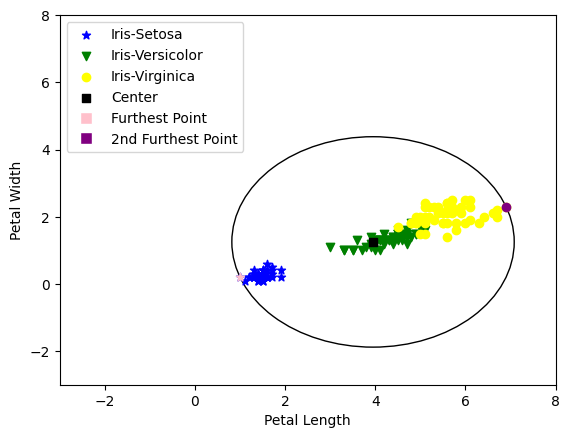

O Hyper-Sphere Center: (3.95, 1.25)
O Hyper-Sphere Radius: 3.13


In [23]:
import numpy as np
from matplotlib.patches import Circle

furthest_point = np.array(furthest_point)
second_furthest_point = np.array(second_furthest_point)

center_point = (furthest_point + second_furthest_point) / 2
radius = distance_between_points / 2

circle = Circle(tuple(center_point), radius, fill=False, color='black')

x_min, x_max = 0, 7
y_min, y_max = 0, 7


label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}


X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

cmap = ListedColormap(["#a5d8ff", "#a5ffa6", "#feffa5"])

fig, axes = plt.subplots()

axes.add_artist(circle)

plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
plt.scatter(furthest_point[0],
            furthest_point[1],
            marker=label_to_marker[furthest_point_class],
            c="pink")
plt.scatter(second_furthest_point[0],
            second_furthest_point[1],
            marker=label_to_marker[second_furthest_point_class],
            c="purple")
plt.scatter(center_point[0], center_point[1], marker="s", c="black", label="Center")
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")


furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='pink',
    markersize=8,
    label='Furthest Point'
)

second_furthest_point_legend = Line2D(
    [0], [0],
    marker='s',
    color='w',
    markerfacecolor='purple',
    markersize=8,
    label='2nd Furthest Point'
)

handles, labels = plt.gca().get_legend_handles_labels()
handles.append(furthest_point_legend)
handles.append(second_furthest_point_legend)
labels.append("Furthest Point")
labels.append("2nd Furthest Point")

plt.legend(handles, labels, loc=2)

plt.show()

print(f"O Hyper-Sphere Center: ({center_point[0]}, {center_point[1]})")
print(f"O Hyper-Sphere Radius: {radius:.2f}")


This is our first hyper-sphere, O, and it contains all the data points from our dataset. In this case, because our features are two-dimensional, this hyper-sphere is a circle, but, as the feature space increases in dimensions, the ball has the same dimensions as the features. The direction that goes from one of the furthest points to another is considered the direction of highest variability. Now, we project every other data point into this line and split it in two sections, with the goal of equally distributing the number of points. 

Consider the current dataset as $X \in \mathbb{R}^{N}$, where $N$ is the number of dimensions in our dataset (in this case, since there are only two features, $N=2$). To project our dataset to a single line, we need a direction vector $w$ so that $w \in \mathbb{R}^{N}$. The projection $z$ is obtained through $z = w^{T}x$ and it is posisble to define the direction vector $u$ of the projection line as $u = b - a$ where $a$ and $b$ are the two opposite points introduced earlier. A projection of a data point into a line means that the resulting point is the closest point belonging to this line. Considering the equation that defines the line between $a$ and $b$ as $l(t) = a + ut$, we get that the euclidean distance between any random point ($d(x)$) to this line is:

$$
d(x) = (x - (a + ut))^2
$$

We can elaborate this distance as:

$$
\begin{aligned}
    d(x) &= (x - a - ut)^{T}(x - a - ut) \\
    \Leftrightarrow d(x) &= (x - a - ut)^{T}(x - a - ut) \\
    \Leftrightarrow d(x) &= (x - a)^{T}(x - a) - 2 (x - a)(ut) + (ut)^{T}(ut) \\
\end{aligned}
$$

Because the goal is to find the minimal distance $d(x)$, by comparing the derivative of the function $d$ in respect to $t$ to 0, it is possible to determine the minimal distance of any point $x$ with respect to $t$:

$$
\begin{aligned}
    & \frac{\partial d(x)}{\partial t} d(x) = 0 \\
    \Leftrightarrow & - 2u (x - a) + 2u^{T}ut = 0 \\
    \Leftrightarrow & 2u^{T}ut = 2u (x - a) \\
    \Leftrightarrow & t = \frac{2u (x - a)}{2u^{T}u} \\
    \Leftrightarrow & t = \frac{u (x - a)}{u^{T}u} \\
\end{aligned}
$$

Replacing $u$ by $b - a$, we get:

$$
\begin{aligned}
    t &= \frac{(b - a) (x - a)}{(b - a)^{T} (b - a)} \\
    \Leftrightarrow t &= \frac{(b - a) (x - a)}{||b - a||}
\end{aligned}
$$

Where:

$$
||b - a|| = \sqrt{\sum_{n}^{N} \left( (b_{n} - a_{n})^{2} \right)} 
$$

If you prefer the $u$ notation, it is common to convert it to the unit vector, by performing:

$$
\hat{u} = u / ||u|| \\
\Leftrightarrow \hat{u} = (b - a) / ||b - a||
$$

And the projection equation can be simplified to:
$$
t = \hat{u} (x - a)
$$

$t$ will be the 1D variable that corresponds to the projection of the data points on the line between the two far points. Then, the data is split on the median, and the process of selecting the two furthest points begins again.

In [24]:
def calculate_norm(arr: np.ndarray):
    """Calculates the norm of a given vector"""
    return np.sqrt(np.sum(arr ** 2))

a = furthest_point
b = second_furthest_point

u = a - b
u_norm = calculate_norm(u)
unit_vector = u / u_norm

data_points_projection = unit_vector @ (X - a).T
points_projection_pair = np.c_[X, data_points_projection]

first_split = points_projection_pair[
                data_points_projection < np.median(data_points_projection)
            ]
second_split = points_projection_pair[
                data_points_projection >= np.median(data_points_projection)
            ]

splits = [first_split, second_split]

trees = {0: [[center_point, float(round(radius, 2))]]}

print(trees)


{0: [[array([3.95, 1.25]), 3.13]]}


After dividing the datapoints by the median, we repeat the same process for every hypersphere until the number of points inside of it is smaller than the number of leaves allowed. The number of leaves allowed is an hyperparameter and we tune it based on our needs, considering the equilibrium between memory and calculation speed. The higher the number of leaves, the higher the number of calculations to be performed during inference using brute-force. The lower the number of leaves, the larger the memory required to store the tree, as it will have more nodes. `scikit-learn` default value for this parameter is 40. To make this more visually interesting, the number of leaves will be reduced in order to plot more hyperspheres.

In [25]:
n_leaves = 20

def get_norm(arr: np.ndarray):
    """Calculates the norm of a given vector"""
    return np.sqrt(np.sum(arr ** 2))

def euclidean_dist_fun(point1, point2):
    """Calculates the Euclidean distance between two
    given points"""
    sum_diffs = 0
    for dim, _ in enumerate(point1):
        sum_diffs += (point1[dim] - point2[dim]) ** 2

    return sum_diffs ** (1 / 2)


all_trees_leaves_pass = False
depth = 1
splits = [split[:,:2] for split in splits]


new_splits = []
while not all_trees_leaves_pass:
    n_leaves_trees = []
    trees[depth] = []
    new_splits = []

    for split in splits:
        random_point = choice(split)

        max_distance = 0
        furthest_point = random_point
        for pt in split:
            distance = euclidean_dist_fun(random_point, pt)
            if distance > max_distance:
                max_distance = distance
                furthest_point = pt

        diameter = 0
        second_furthest_point = random_point
        for pt in split:
            distance = euclidean_dist_fun(furthest_point, pt)
            if distance > diameter:
                diameter = distance
                second_furthest_point = pt

        center = (np.array(furthest_point) + np.array(second_furthest_point)) / 2
        radius = diameter / 2

        radius = 0
        for pt in split:
            distance_center = euclidean_dist_fun(pt, center)
            if distance_center > radius:
                radius = distance_center

        trees[depth].append([center, round(radius, 2)])

        if len(split) >= n_leaves:
            u = furthest_point - second_furthest_point
            u_norm = get_norm(u)
            unit_vector = u / u_norm

            data_points_projection = unit_vector @ (split - furthest_point).T

            first_split = split[
                    data_points_projection < np.median(data_points_projection)
                ]
            second_split = split[
                    data_points_projection >= np.median(data_points_projection)
                ]

            if len(first_split) > 0:
                new_splits.append(first_split)
                n_leaves_trees.append(len(first_split))
            if len(second_split) > 0:
                new_splits.append(second_split)
                n_leaves_trees.append(len(second_split))

        else:
            new_splits.append(split)
            n_leaves_trees.append(len(split))

    all_trees_leaves_pass = all(n < n_leaves for n in n_leaves_trees) \
                            and not \
                            any(len(s) >= n_leaves for s in new_splits)

    splits = new_splits
    depth += 1


############################################################
Hyper-Sphere Tree Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13


############################################################
Hyper-Sphere Tree Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37


############################################################
Hyper-Sphere Tree Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 1
Hyper-Sphere Center: (6.00, 2.10)
Hyper-Sphere Radius: 0.95


############################################################
Hyper-Sphere Tree Depth: 2
Hyper-Sphere Node: 2
Hyper-Sphere Center: (1.25, 0.30)
Hy

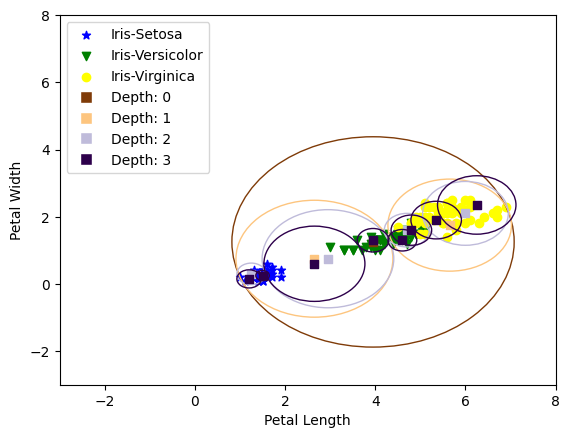

In [26]:
from matplotlib import colormaps
from matplotlib.patches import Circle

cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

def norm(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)


x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_setosa = X[y==0]
X_versicolor = X[y==1]
X_virginica = X[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(norm(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere Tree Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


The fully constructed optimized algorithm, that goes from data loading to plotting, would look something like this, using NumPy. The results differ from the previous cell because of the change in random point selection.

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']


############################################################
Hyper-Sphere ID: 21
Hyper-Sphere Depth: 2
Hyper-Sph

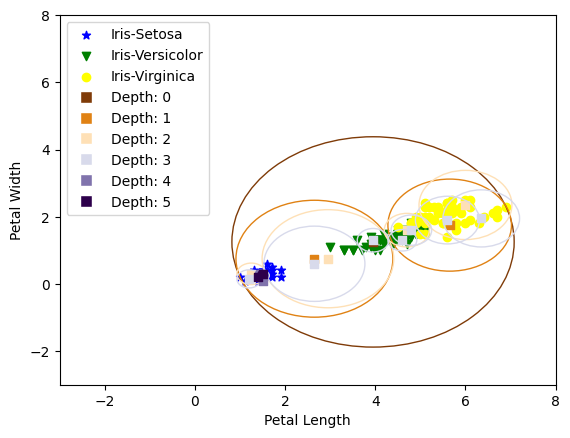

In [57]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

random_state = 8
n_leaves = 20

rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

def norm_(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

all_leaves_small = False
depth = 0
splits: list[np.ndarray] = [X]
trees: dict[int, list] = {}
new_splits: list[np.ndarray] = []

while True:
    trees[depth] = []
    new_splits = []
    depth_node_counter = 0

    for split in splits:
        split_points = split[:, 1:]

        split_points = np.atleast_2d(split_points)
        pivot = split_points[rng.integers(len(split_points))]

        diff1 = split_points - pivot
        dist1 = np.einsum('ij,ij->i', diff1, diff1)
        furthest = split_points[np.argmax(dist1)]

        diff2 = split_points - furthest
        dist2 = np.einsum('ij,ij->i', diff2, diff2)
        idx2 = np.argmax(dist2)
        opposite = split_points[idx2]
        center = (furthest + opposite) * 0.5

        diff_center = split_points - center
        diff_center = np.einsum('ij,ij->i', diff_center, diff_center)
        radius = float(np.sqrt(np.max(diff_center)))

        split_indexes = None

        if len(split) > n_leaves:
            u = furthest - opposite
            unit_vector = u / np.linalg.norm(u)

            projections = (split_points - furthest) @ unit_vector
            median_val = np.median(projections)
            mask = projections < median_val
            first_split = split[mask]
            second_split = split[~mask]

            if len(first_split) > 0:
                new_splits.append(first_split)
            if len(second_split) > 0:
                new_splits.append(second_split)

            if len(first_split) > 0 and len(second_split) > 0:
                childs = [
                    str(depth + 1) + str(depth_node_counter),
                    str(depth + 1) + str(depth_node_counter + 1)
                ]
                depth_node_counter += 2
            else:
                childs = None
                split_indexes = split[:, 0]
        else:
            childs = None
            split_indexes = split[:, 0]

        trees[depth].append([center, round(radius, 2), childs, split_indexes])

    if not new_splits:
        break

    if all(len(s) < n_leaves for s in new_splits):
        splits = new_splits
        depth += 1
        continue

    splits = new_splits
    depth += 1


cmap = colormaps['PuOr']
vmin = min(trees.keys())
vmax = max(trees.keys())

x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_points = X[:, 1:]

X_setosa = X_points[y==0]
X_versicolor = X_points[y==1]
X_virginica = X_points[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in trees.items():
    color = cmap(norm_(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


Now, doing the same thing with JAX instead of NumPy:

############################################################
Hyper-Sphere ID: 00
Hyper-Sphere Depth: 0
Hyper-Sphere Node: 0
Hyper-Sphere Center: (3.95, 1.25)
Hyper-Sphere Radius: 3.13
Hyper-Sphere Children: ['10', '11']
Hyper-Sphere Number of Points: 14


############################################################
Hyper-Sphere ID: 10
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 0
Hyper-Sphere Center: (5.65, 1.75)
Hyper-Sphere Radius: 1.37
Hyper-Sphere Children: ['20', '21']
Hyper-Sphere Number of Points: 14


############################################################
Hyper-Sphere ID: 11
Hyper-Sphere Depth: 1
Hyper-Sphere Node: 1
Hyper-Sphere Center: (2.65, 0.75)
Hyper-Sphere Radius: 1.74
Hyper-Sphere Children: ['22', '23']
Hyper-Sphere Number of Points: 14


############################################################
Hyper-Sphere ID: 20
Hyper-Sphere Depth: 2
Hyper-Sphere Node: 0
Hyper-Sphere Center: (4.70, 1.60)
Hyper-Sphere Radius: 0.50
Hyper-Sphere Children: ['30', '31']
Hyper-Sphere

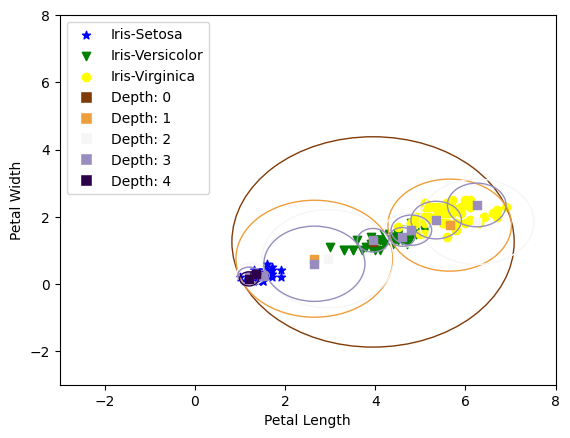

In [51]:
from jax.random import PRNGKey, randint, split as jax_split
import jax.numpy as jnp
from typing import cast, Dict
from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from matplotlib import colormaps
from matplotlib.patches import Circle
from matplotlib.lines import Line2D

random_state = 8
n_leaves = 20

key = PRNGKey(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(jnp.float32)
y = iris['target']

index_col = jnp.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = jnp.hstack((index_col, X))

def normalize(value, value_min, value_max):
    """Min-max normalization"""
    return (value - value_min) / (value_max - value_min)

all_leaves_small = False
depth = 0
splits: list[jnp.ndarray] = [X]
jax_trees: dict[int, list] = {}
new_splits: list[jnp.ndarray] = []

while True:
    jax_trees[depth] = []
    new_splits = []
    depth_node_counter = 0

    for split in splits:
        split_points = split[:, 1:]
        split_points = jnp.atleast_2d(split_points)

        key, subkey = jax_split(key)
        pivot = split_points[randint(subkey, (), 0, len(split_points))]

        diff1 = split_points - pivot
        dist1 = jnp.einsum('ij,ij->i', diff1, diff1)
        furthest = split_points[jnp.argmax(dist1)]

        diff2 = split_points - furthest
        dist2 = jnp.einsum('ij,ij->i', diff2, diff2)
        idx2 = jnp.argmax(dist2)
        opposite = split_points[idx2]
        center = (furthest + opposite) * 0.5

        diff_center = split_points - center
        diff_center = jnp.einsum('ij,ij->i', diff_center, diff_center)
        radius = float(jnp.sqrt(jnp.max(diff_center)))

        if len(split) > n_leaves:
            u = furthest - opposite
            unit_vector = u / jnp.linalg.norm(u)

            projections = (split_points - furthest) @ unit_vector
            median_val = jnp.median(projections)
            mask = projections < median_val
            first_split = split[mask]
            second_split = split[~mask]

            if len(first_split) > 0:
                new_splits.append(first_split)
            if len(second_split) > 0:
                new_splits.append(second_split)

            if len(first_split) > 0 and len(second_split) > 0:
                childs = [
                    str(depth + 1) + str(depth_node_counter),
                    str(depth + 1) + str(depth_node_counter + 1)
                ]
                depth_node_counter += 2
            else:
                childs = None
                split_indexes = split[:, 0]
        else:
            childs = None
            split_indexes = split[:, 0]

        jax_trees[depth].append([center, round(radius, 2), childs, split_indexes])

    if not new_splits:
        break

    if all(len(s) < n_leaves for s in new_splits):
        splits = new_splits
        depth += 1
        continue

    splits = new_splits
    depth += 1

cmap = colormaps['PuOr']
vmin = min(jax_trees.keys())
vmax = max(jax_trees.keys())

x_min, x_max = 0, 7
y_min, y_max = 0, 7

label_to_marker = {
    0: "*",
    1: "v",
    2: "o",
}

X_points = X[:, 1:]

X_setosa = X_points[y==0]
X_versicolor = X_points[y==1]
X_virginica = X_points[y==2]

fig, axes = plt.subplots()


plt.axis((-3.,8., -3.,8.))
plt.scatter(X_setosa[:,0], X_setosa[:,1], marker="*", c="blue", label="Iris-Setosa")
plt.scatter(X_versicolor[:,0], X_versicolor[:,1], marker="v", c="green", label="Iris-Versicolor")
plt.scatter(X_virginica[:,0], X_virginica[:,1], marker="o", c="yellow", label="Iris-Virginica")
handles, labels = plt.gca().get_legend_handles_labels()
plt.xlabel("Petal Length")
plt.ylabel("Petal Width")

for depth, nodes in jax_trees.items():
    color = cmap(normalize(depth, vmin, vmax))
    for node_id, node in enumerate(nodes):
        center_point, radius, children, split_indexes = node
        circle = Circle(tuple(center_point), radius, fill=False, color=color)
        axes.add_artist(circle)
        plt.scatter(center_point[0], center_point[1], marker="s", color=color, label="Center")

        print("#" * 60)
        print(f"Hyper-Sphere ID: {depth}{node_id}")
        print(f"Hyper-Sphere Depth: {depth}")
        print(f"Hyper-Sphere Node: {node_id}")
        print(f"Hyper-Sphere Center: ({center_point[0]:.2f}, {center_point[1]:.2f})")
        print(f"Hyper-Sphere Radius: {radius:.2f}")
        if children:
            print(f"Hyper-Sphere Children: {children}")
        if split_indexes is not None:
            print(f"Hyper-Sphere Number of Points: {len(split_indexes)}")
        print("\n")

    depth_legend = Line2D(
        [0], [0],
        marker='s',
        color='w',
        markerfacecolor=color,
        markersize=8,
        label=f'Depth: {depth}'
    )
    handles.append(depth_legend)
    labels.append(f"Depth: {depth}")

plt.legend(handles, labels, loc=2)
plt.show()


After constructing the tree, the next step is using it to make predictions.

In [52]:
import numpy as np
from typing import cast, Dict
from sklearn.datasets import load_iris

# Loading the same point we did previously
query_point = [5.3, 1.8]

# Loading the data exactly the same as before
random_state = 8
n_leaves = 20

rng = np.random.default_rng(random_state)

iris = cast(Dict, load_iris())
X = iris['data'][:, 2:].astype(np.float32)
y = iris['target']

index_col = np.arange(X.shape[0], dtype=int).reshape(-1, 1)
X = np.hstack((index_col, X))

# Selecting a tree to work with.
# You can change to jax_trees, as well.
tree = trees


In [ ]:
queue = ['00']
k = 5

def get_euclidean_distance(point1, point2):
    """Calculates the Euclidean distance between two points"""
    return np.sqrt(np.sum((point1 - point2) ** 2, axis=0))

def get_k_neighbours(k_best, leaves, query):
    """Updates the list of the K-closest points"""
    for leave in leaves:
        dist = get_euclidean_distance(query, leave)

        if dist < k_best[-1][1]:
            k_best[-1] = [leave, dist]
            k_best.sort(key=lambda x: x[1])

    return k_best


k_best_list = [[np.array([0, 0]), float('inf')]] * k

while True:
    for node in queue:
        node = tree[int(node[0])][int(node[1])]
        center = node[0]
        radius = node[1]
        best_node_distance = get_euclidean_distance(center, query_point) - radius

        if node[3] is None:
            queue += node[2]
        else:
            leaves_to_check = X[np.array(node[3], dtype=int)][:, 1:]
            k_best_list = get_k_neighbours(k_best_list, leaves_to_check, query_point)

    if not queue:
        break

print(k_best_list)


### KD Tree <a id="kd-tree"></a>